In [1]:
import numpy as np
import matplotlib.image as img
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

# Convolution

In [2]:
def convolution2d(image, kernel):
    m, n = kernel.shape
    if m == n:
        y, x = image.shape
        y = y - m + 1
        x = x - m + 1
        new_image = np.zeros((y, x))
        for i in range(y):
            for j in range(x):
                new_image[i][j] = np.sum(image[i:i+m, j:j+m] * kernel)
    return new_image

# MSE

In [3]:
def calculate_mse(img_python, img_sv):    
    min_shape = (min(img_python.shape[0], img_sv.shape[0]), min(img_python.shape[1], img_sv.shape[1]))
    squared_diff = (img_python[:min_shape[0], :min_shape[1]] - img_sv[:min_shape[0], :min_shape[1]]) ** 2
    return np.mean(squared_diff)

# Main

In [4]:
img = Image.open("lena.bmp")

img = np.array(img, dtype=np.uint8)
if len(img.shape) == 3: 
    img = np.mean(image, axis=2)
height, width = img.shape

with open("test.ppm", "w") as f:
    f.write("P2\n")
    f.write("# Generated\n")
    f.write(f"{width} {height}\n")
    f.write("255\n")

    for y in range(height):
        for x in range(width):
            f.write(f"{img[y, x]} ")
        f.write("\n")


In [5]:
img = np.pad(img, pad_width=1, mode='constant', constant_values=0)

kernel = 1/16 * np.array([
    [1, 2, 1],
    [2, 4, 2],
    [1, 2, 1]
])

result = convolution2d(img, kernel)

In [6]:
result

array([[ 90.125 , 120.    , 119.6875, ..., 124.    , 113.5625,  77.25  ],
       [120.3125, 160.125 , 159.5   , ..., 165.125 , 151.3125, 103.    ],
       [120.4375, 160.375 , 159.5625, ..., 165.1875, 151.4375, 103.0625],
       ...,
       [ 37.5625,  51.3125,  53.875 , ..., 104.875 , 104.6875,  78.375 ],
       [ 37.125 ,  51.5   ,  55.    , ..., 106.3125, 107.6875,  81.5625],
       [ 27.875 ,  38.8125,  41.75  , ...,  80.125 ,  81.625 ,  62.1875]],
      shape=(512, 512))

# Загрузка изображения из SV

In [7]:
img_sv = Image.open("result.ppm")
print(img_sv.size)
print(img_sv.format)

(512, 512)
PPM


In [8]:
img_sv = np.array(img_sv, dtype=np.uint8)

In [9]:
img_sv

array([[ 90, 120, 119, ..., 124, 113,  77],
       [120, 160, 159, ..., 165, 151, 103],
       [120, 160, 159, ..., 165, 151, 103],
       ...,
       [ 37,  51,  53, ..., 104, 104,  78],
       [ 37,  51,  55, ..., 106, 107,  81],
       [ 27,  38,  41, ...,  80,  81,  62]], shape=(512, 512), dtype=uint8)

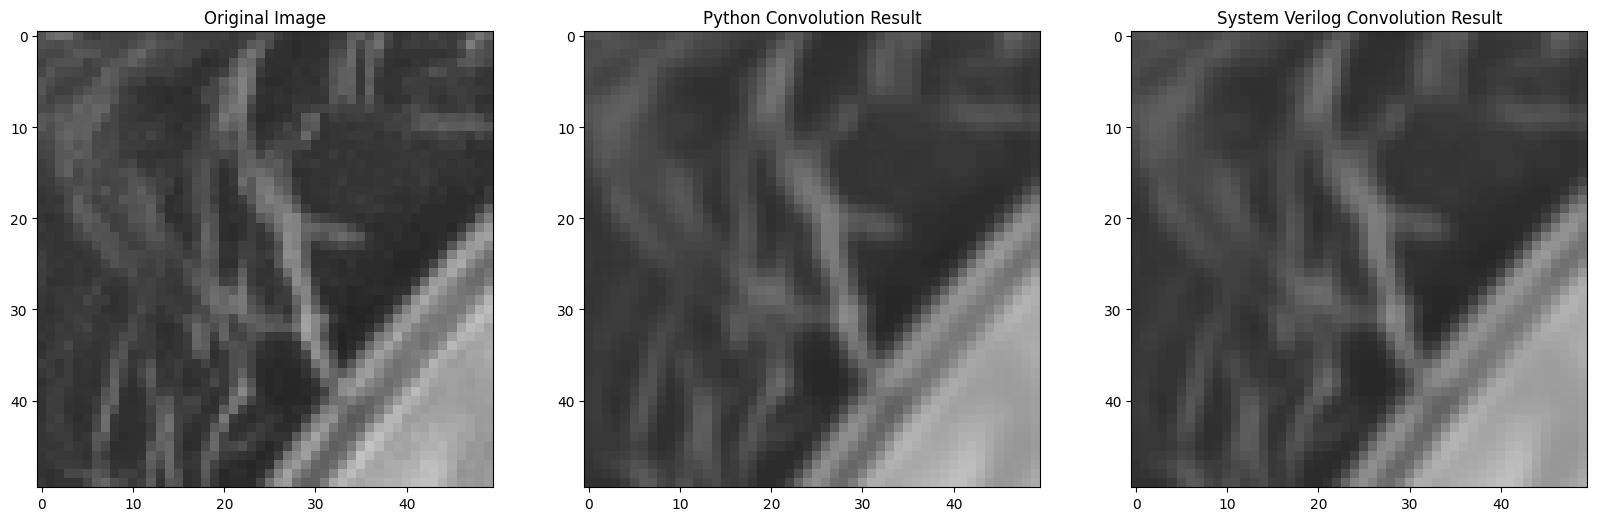

In [10]:
plt.figure(figsize=(20, 10))
plt.subplot(1, 3, 1)
plt.title("Original Image")
# plt.imshow(img, cmap='gray', vmin = 0, vmax = 255)
plt.imshow(img[200:250,200:250], cmap='gray', vmin = 0, vmax = 255)

plt.subplot(1, 3, 2)
plt.title("Python Convolution Result")
# plt.imshow(result, cmap='gray', vmin = 0, vmax = 255)
plt.imshow(result[200:250,200:250], cmap='gray', vmin = 0, vmax = 255)

plt.subplot(1, 3, 3)
plt.title("System Verilog Convolution Result")
# plt.imshow(img_sv, cmap='gray', vmin = 0, vmax = 255)
plt.imshow(img_sv[200:250,200:250], cmap='gray', vmin = 0, vmax = 255)
plt.show()

In [11]:
mse = calculate_mse(result, img_sv)
print(mse)

0.3034922033548355


In [12]:
count = 0
size = 4
matrix = np.zeros((size,size))

for i in range(size):
    for j in range(size):
        count += 1
        matrix[i][j] = count
        
matrix = np.pad(matrix, pad_width=1, mode='constant', constant_values=0)

In [13]:
matrix

array([[ 0.,  0.,  0.,  0.,  0.,  0.],
       [ 0.,  1.,  2.,  3.,  4.,  0.],
       [ 0.,  5.,  6.,  7.,  8.,  0.],
       [ 0.,  9., 10., 11., 12.,  0.],
       [ 0., 13., 14., 15., 16.,  0.],
       [ 0.,  0.,  0.,  0.,  0.,  0.]])

In [14]:
kernel = np.array([
    [0, 0, 0],
    [0, 1, 0],
    [0, 0, 0]
])
result = convolution2d(matrix, kernel)

In [15]:
result

array([[ 1.,  2.,  3.,  4.],
       [ 5.,  6.,  7.,  8.],
       [ 9., 10., 11., 12.],
       [13., 14., 15., 16.]])